# NHANES Pulse Consumption — Country/Region of Origin Analysis

Examines pulse consumption stratified by country or region of origin, using
NHANES 1999–2018 (10 cycles).

## Data availability and limitations

NHANES public-use files provide country of birth only as US vs. non-US (DMDBORN variants),
without specific country names. Region-of-origin groups are approximated using
race/ethnicity and nativity:

| Requested group | NHANES proxy | Cycles available |
|---|---|---|
| Latin America | Foreign-born Hispanic (RIDRETH1 ∈ {1,2} + born outside US) | All 10 |
| China / SE / E Asia | Non-Hispanic Asian (RIDRETH3=6) | 2011–2018 only (4 cycles) |
| South Asia | **Cannot distinguish from E/SE Asian** in NHANES public data | — |
| Eastern Europe | **Cannot distinguish from Western European** in NHANES public data | — |
| Western Europe | Foreign-born Non-Hispanic White (RIDRETH1=3 + born outside US) | All 10 |

For 1999–2010, Non-Hispanic Asian is not a distinct race/ethnicity category; "Other Race,
foreign-born" (RIDRETH1=5 + not born in US) serves as a cruder proxy and is shown separately.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import display

pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 120)

DATA_DIR = os.path.abspath(os.path.join('..', 'data'))
DERIVED = os.path.join(DATA_DIR, 'derived')

df = pd.read_parquet(os.path.join(DERIVED, 'pulse_consumption.parquet'))

n_cycles = df['CYCLE'].nunique()
df['WT_POOLED'] = df['WTDRD1'] / n_cycles
has_wt = df['WT_POOLED'].notna() & (df['WT_POOLED'] > 0)
dfw = df[has_wt].copy()

print(f'Loaded {len(dfw):,} participants across {df["CYCLE"].nunique()} cycles')
print(f'\nNativity:')
print(dfw['NATIVITY'].value_counts(dropna=False))
print(f'\nOrigin groups:')
print(dfw['ORIGIN_GROUP'].value_counts())

Loaded 48,736 participants across 10 cycles

Nativity:
NATIVITY
US-born         36036
Foreign-born     9129
Mexico-born      3551
NaN                20
Name: count, dtype: int64

Origin groups:
ORIGIN_GROUP
NH White (US-born)                            20800
NH Black (US-born)                             9200
Latin America (foreign-born Hispanic)          7879
Latin America (US-born Hispanic)               4623
Asia (Non-Hispanic Asian, 2011+)               2282
Other/Unknown                                  1116
Europe (foreign-born NH White)                 1060
NH Black (foreign-born)                         992
Asia (Other Race, foreign-born, 1999-2010)      784
Name: count, dtype: int64


In [2]:
def weighted_mean(values, weights):
    mask = values.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    return np.average(values[mask], weights=weights[mask])

def weighted_pct(binary, weights):
    return 100 * weighted_mean(binary, weights)

def weighted_ci(values, weights, alpha=0.05):
    mask = values.notna() & weights.notna() & (weights > 0)
    v = values[mask].values
    w = weights[mask].values
    wm = np.average(v, weights=w)
    n_eff = (w.sum())**2 / (w**2).sum()
    wvar = np.average((v - wm)**2, weights=w)
    se = np.sqrt(wvar / n_eff)
    z = stats.norm.ppf(1 - alpha / 2)
    return wm - z * se, wm + z * se

def group_stats(data, consumer_col, oz_col, wt_col):
    """Compute prevalence and consumption for a subgroup."""
    if len(data) == 0:
        return dict(N=0, n_consumers=0, prev_pct=np.nan,
                    prev_ci_lo=np.nan, prev_ci_hi=np.nan,
                    oz_all=np.nan, oz_consumers=np.nan)
    cons = data[data[consumer_col] == 1]
    prev = weighted_pct(data[consumer_col], data[wt_col])
    lo, hi = weighted_ci(data[consumer_col], data[wt_col])
    oz_all = weighted_mean(data[oz_col], data[wt_col])
    oz_cons = weighted_mean(cons[oz_col], cons[wt_col]) if len(cons) > 0 else np.nan
    return dict(
        N=len(data), n_consumers=int(data[consumer_col].sum()),
        prev_pct=prev, prev_ci_lo=100*lo, prev_ci_hi=100*hi,
        oz_all=oz_all, oz_consumers=oz_cons,
    )

## Pulse consumption by region of origin — all cycles pooled

Using the broad measure (all FPED-linked pulse codes) with pooled 10-cycle survey weights.

In [3]:
# Define ordered groups for display
# Asian group: combine 2011+ NH Asian and 1999-2010 Other Race foreign-born together
# We separate them in the table to make the coverage limitation clear
ORIGIN_GROUPS_DISPLAY = [
    'Latin America (foreign-born Hispanic)',
    'Latin America (US-born Hispanic)',
    'Asia (Non-Hispanic Asian, 2011+)',
    'Asia (Other Race, foreign-born, 1999-2010)',
    'Europe (foreign-born NH White)',
    'NH White (US-born)',
    'NH Black (US-born)',
    'NH Black (foreign-born)',
]

rows = []
for grp in ORIGIN_GROUPS_DISPLAY:
    sub = dfw[dfw['ORIGIN_GROUP'] == grp]
    stats_b = group_stats(sub, 'IS_CONSUMER', 'PULSE_OZ_EQ', 'WT_POOLED')
    stats_r = group_stats(sub, 'IS_CONSUMER_R', 'PULSE_OZ_EQ_R', 'WT_POOLED')
    rows.append({
        'Origin group': grp,
        'N': stats_b['N'],
        'Consumers (broad)': stats_b['n_consumers'],
        'Prev % (broad)': stats_b['prev_pct'],
        '95% CI': f'({stats_b["prev_ci_lo"]:.1f}–{stats_b["prev_ci_hi"]:.1f})',
        'oz/day all (broad)': stats_b['oz_all'],
        'oz/day consumers (broad)': stats_b['oz_consumers'],
        'Prev % (restricted)': stats_r['prev_pct'],
        'oz/day all (restricted)': stats_r['oz_all'],
    })

origin_df = pd.DataFrame(rows)
display(origin_df.style.format({
    'N': '{:,}', 'Consumers (broad)': '{:,}',
    'Prev % (broad)': '{:.1f}', 'Prev % (restricted)': '{:.1f}',
    'oz/day all (broad)': '{:.2f}', 'oz/day consumers (broad)': '{:.2f}',
    'oz/day all (restricted)': '{:.2f}',
}).set_caption('Pulse consumption by region of origin (weighted, broad measure)'))

,Origin group,N,Consumers (broad),Prev % (broad),95% CI,oz/day all (broad),oz/day consumers (broad),Prev % (restricted),oz/day all (restricted)
0,Latin America (foreign-born Hispanic),"7,879","3,117",38.4,(36.9–39.9),1.27,3.31,38.0,1.27
1,Latin America (US-born Hispanic),"4,623","1,272",25.0,(23.1–26.8),0.70,2.79,24.3,0.69
2,"Asia (Non-Hispanic Asian, 2011+)","2,282",648,27.8,(25.6–30.1),0.66,2.36,23.6,0.64
3,"Asia (Other Race, foreign-born, 1999-2010)",784,171,18.3,(14.7–22.0),0.47,2.57,17.1,0.47
4,Europe (foreign-born NH White),"1,060",165,18.1,(15.0–21.2),0.42,2.30,16.8,0.41
5,NH White (US-born),"20,800","3,213",16.7,(16.0–17.4),0.36,2.17,15.7,0.36
6,NH Black (US-born),"9,200","1,178",13.2,(12.4–14.1),0.34,2.56,12.5,0.34
7,NH Black (foreign-born),992,211,20.7,(17.6–23.9),0.56,2.70,20.0,0.56


## Visualization: Prevalence and mean consumption by origin group

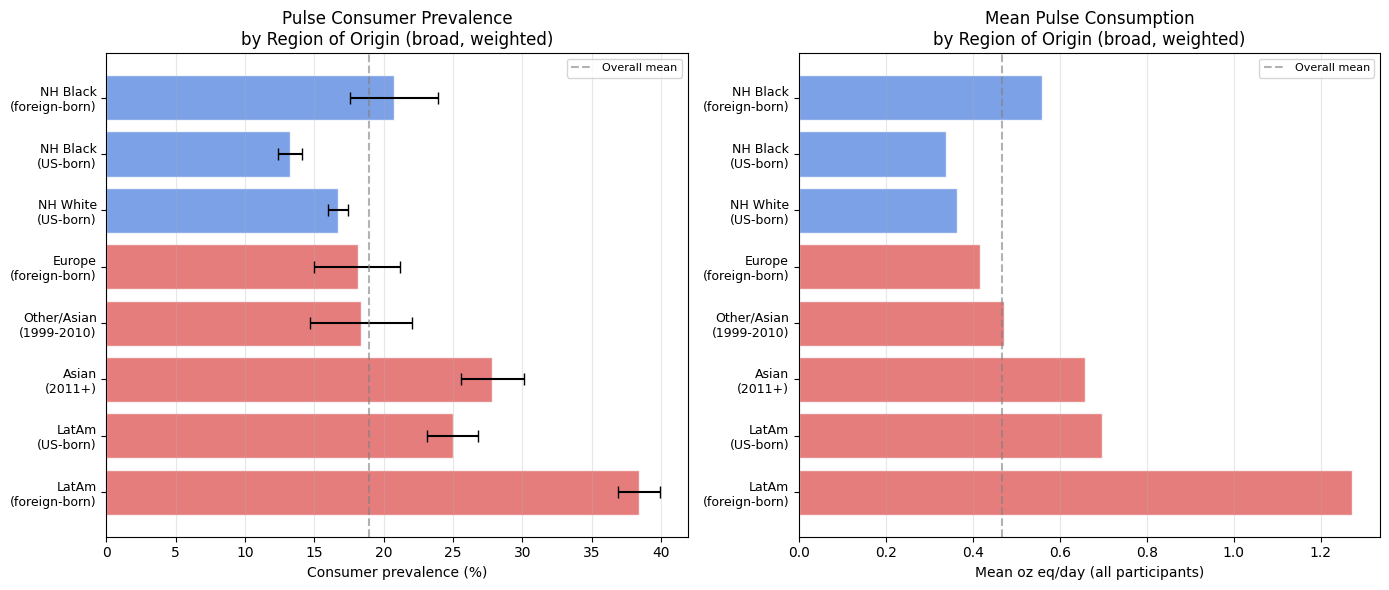

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Short labels for plot
short_labels = {
    'Latin America (foreign-born Hispanic)':         'LatAm\n(foreign-born)',
    'Latin America (US-born Hispanic)':              'LatAm\n(US-born)',
    'Asia (Non-Hispanic Asian, 2011+)':              'Asian\n(2011+)',
    'Asia (Other Race, foreign-born, 1999-2010)':   'Other/Asian\n(1999-2010)',
    'Europe (foreign-born NH White)':                'Europe\n(foreign-born)',
    'NH White (US-born)':                            'NH White\n(US-born)',
    'NH Black (US-born)':                            'NH Black\n(US-born)',
    'NH Black (foreign-born)':                       'NH Black\n(foreign-born)',
}

plot_df = origin_df[origin_df['N'] > 0].copy()
labels = [short_labels.get(g, g) for g in plot_df['Origin group']]
x = range(len(plot_df))

# Parse CI for error bars
ci_lo = plot_df['Prev % (broad)'] - plot_df['95% CI'].apply(
    lambda ci: float(ci.strip('()').split('–')[0]))
ci_hi = plot_df['95% CI'].apply(
    lambda ci: float(ci.strip('()').split('–')[1])) - plot_df['Prev % (broad)']

colors = ['#e05c5c' if 'LatAm' in l or 'Asian' in l or 'Other/Asian' in l or 'Europe' in l
          else '#5c8ae0' for l in labels]

ax1.barh(x, plot_df['Prev % (broad)'], xerr=[ci_lo.values, ci_hi.values],
         capsize=4, color=colors, alpha=0.8, edgecolor='white')
ax1.set_yticks(x)
ax1.set_yticklabels(labels, fontsize=9)
ax1.set_xlabel('Consumer prevalence (%)')
ax1.set_title('Pulse Consumer Prevalence\nby Region of Origin (broad, weighted)')
ax1.axvline(x=weighted_pct(dfw['IS_CONSUMER'], dfw['WT_POOLED']),
            color='gray', linestyle='--', alpha=0.6, label='Overall mean')
ax1.legend(fontsize=8)
ax1.grid(axis='x', alpha=0.3)

ax2.barh(x, plot_df['oz/day all (broad)'], color=colors, alpha=0.8, edgecolor='white')
ax2.set_yticks(x)
ax2.set_yticklabels(labels, fontsize=9)
ax2.set_xlabel('Mean oz eq/day (all participants)')
ax2.set_title('Mean Pulse Consumption\nby Region of Origin (broad, weighted)')
ax2.axvline(x=weighted_mean(dfw['PULSE_OZ_EQ'], dfw['WT_POOLED']),
            color='gray', linestyle='--', alpha=0.6, label='Overall mean')
ax2.legend(fontsize=8)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

## Pulse type breakdown by origin group

Which pulses drive consumption in each group?

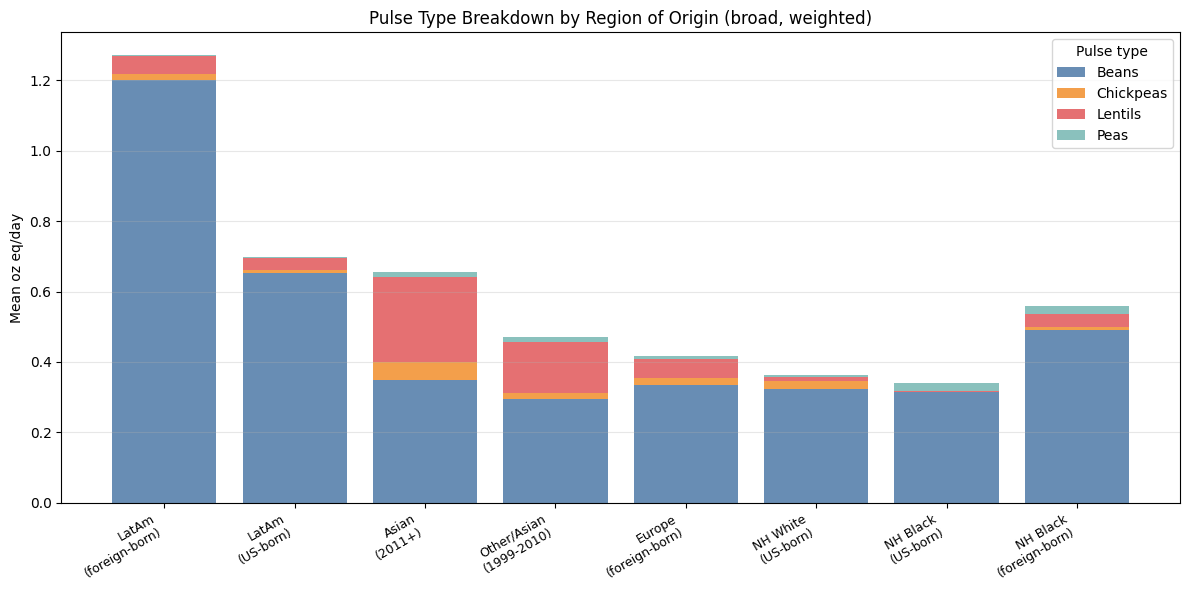

,Origin group,N,beans oz/day,chickpeas oz/day,lentils oz/day,peas oz/day,total oz/day
0,Latin America (foreign-born Hispanic),"7,879",1.201,0.016,0.052,0.003,1.273
1,Latin America (US-born Hispanic),"4,623",0.651,0.009,0.036,0.001,0.697
2,"Asia (Non-Hispanic Asian, 2011+)","2,282",0.350,0.049,0.241,0.017,0.657
3,"Asia (Other Race, foreign-born, 1999-2010)",784,0.293,0.018,0.146,0.013,0.471
4,Europe (foreign-born NH White),"1,060",0.335,0.019,0.054,0.009,0.417
5,NH White (US-born),"20,800",0.322,0.023,0.013,0.005,0.363
6,NH Black (US-born),"9,200",0.314,0.001,0.002,0.021,0.339
7,NH Black (foreign-born),992,0.491,0.009,0.036,0.023,0.559


In [5]:
pulse_type_rows = []
for grp in ORIGIN_GROUPS_DISPLAY:
    sub = dfw[dfw['ORIGIN_GROUP'] == grp]
    if len(sub) == 0:
        continue
    row = {'Origin group': grp, 'N': len(sub)}
    for pt in ['BEANS', 'CHICKPEAS', 'LENTILS', 'PEAS']:
        col = f'PULSE_CUPS_{pt}'
        row[f'{pt.lower()} oz/day'] = weighted_mean(sub[col] * 4, sub['WT_POOLED'])
    row['total oz/day'] = weighted_mean(sub['PULSE_OZ_EQ'], sub['WT_POOLED'])
    pulse_type_rows.append(row)

pt_origin_df = pd.DataFrame(pulse_type_rows)

# Also show as stacked bar chart
fig, ax = plt.subplots(figsize=(12, 6))
pulse_types = ['beans oz/day', 'chickpeas oz/day', 'lentils oz/day', 'peas oz/day']
labels = [short_labels.get(g, g) for g in pt_origin_df['Origin group']]
x = np.arange(len(pt_origin_df))
bottoms = np.zeros(len(pt_origin_df))
colors_pt = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']

for pt, color in zip(pulse_types, colors_pt):
    vals = pt_origin_df[pt].fillna(0).values
    ax.bar(x, vals, bottom=bottoms, label=pt.split()[0].capitalize(),
           color=color, alpha=0.85)
    bottoms += vals

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9, rotation=30, ha='right')
ax.set_ylabel('Mean oz eq/day')
ax.set_title('Pulse Type Breakdown by Region of Origin (broad, weighted)')
ax.legend(title='Pulse type')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

display(pt_origin_df.style.format({
    'N': '{:,}',
    'beans oz/day': '{:.3f}', 'chickpeas oz/day': '{:.3f}',
    'lentils oz/day': '{:.3f}', 'peas oz/day': '{:.3f}',
    'total oz/day': '{:.3f}',
}).set_caption('Mean oz eq/day by pulse type and region of origin'))

## Temporal trends by origin group

How has consumption changed over cycles for each region-of-origin group?

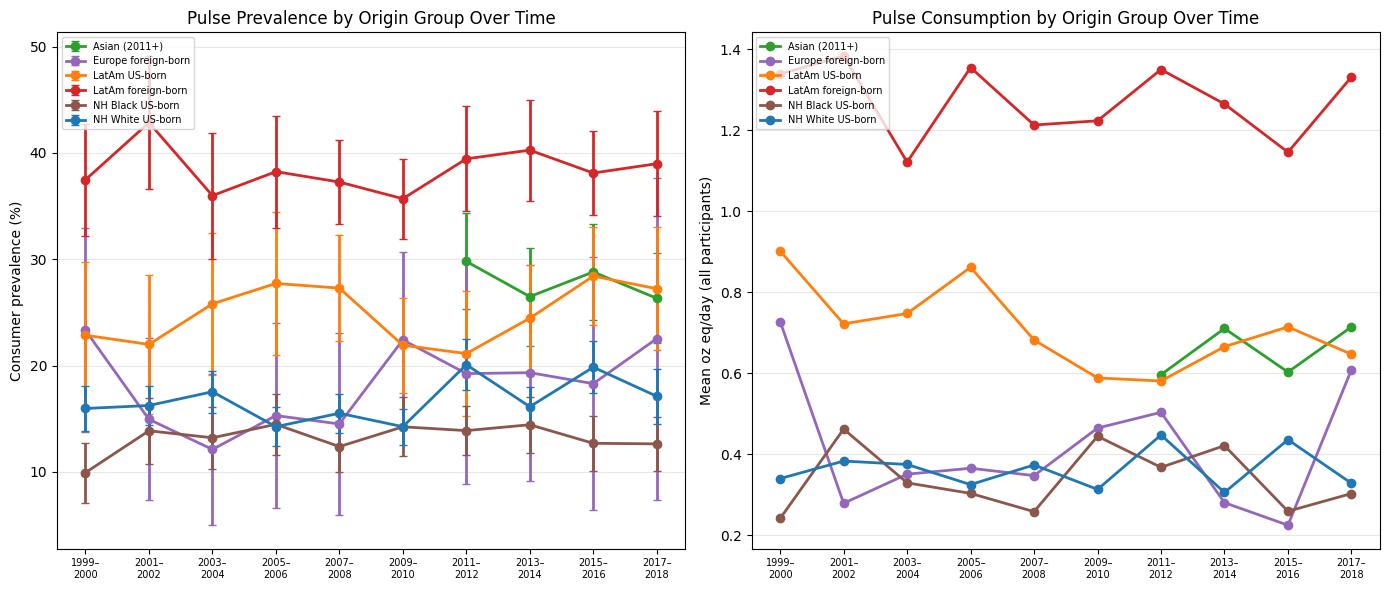

In [6]:
# Focus on groups with enough sample sizes across cycles
TREND_GROUPS = [
    ('Latin America (foreign-born Hispanic)', 'LatAm foreign-born', '#d62728'),
    ('Latin America (US-born Hispanic)',       'LatAm US-born',      '#ff7f0e'),
    ('Asia (Non-Hispanic Asian, 2011+)',        'Asian (2011+)',       '#2ca02c'),
    ('Europe (foreign-born NH White)',          'Europe foreign-born','#9467bd'),
    ('NH White (US-born)',                      'NH White US-born',   '#1f77b4'),
    ('NH Black (US-born)',                      'NH Black US-born',   '#8c564b'),
]

cycles_sorted = sorted(dfw['CYCLE'].unique())

trend_rows = []
for cycle in cycles_sorted:
    sub_cycle = dfw[dfw['CYCLE'] == cycle]
    wt = sub_cycle['WTDRD1']
    for grp, label, color in TREND_GROUPS:
        sub = sub_cycle[sub_cycle['ORIGIN_GROUP'] == grp]
        if len(sub) < 30:
            continue
        s = group_stats(sub, 'IS_CONSUMER', 'PULSE_OZ_EQ', 'WTDRD1')
        trend_rows.append({'Cycle': cycle, 'Group': label,
                           'Prev %': s['prev_pct'], 'CI lo': s['prev_ci_lo'],
                           'CI hi': s['prev_ci_hi'], 'oz all': s['oz_all']})

trend_df = pd.DataFrame(trend_rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
x_map = {c: i for i, c in enumerate(cycles_sorted)}
xlabels = [c.replace('-', '–\n') for c in cycles_sorted]

group_colors = {label: color for _, label, color in TREND_GROUPS}

for grp_label, gdf in trend_df.groupby('Group'):
    x = [x_map[c] for c in gdf['Cycle']]
    color = group_colors.get(grp_label, 'gray')
    ax1.errorbar(x, gdf['Prev %'],
                 yerr=[gdf['Prev %'] - gdf['CI lo'], gdf['CI hi'] - gdf['Prev %']],
                 marker='o', capsize=3, linewidth=2, color=color, label=grp_label)
    ax2.plot(x, gdf['oz all'], 'o-', linewidth=2, color=color, label=grp_label)

for ax in [ax1, ax2]:
    ax.set_xticks(range(len(cycles_sorted)))
    ax.set_xticklabels(xlabels, fontsize=7)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(axis='y', alpha=0.3)

ax1.set_ylabel('Consumer prevalence (%)')
ax1.set_title('Pulse Prevalence by Origin Group Over Time')
ax2.set_ylabel('Mean oz eq/day (all participants)')
ax2.set_title('Pulse Consumption by Origin Group Over Time')

plt.tight_layout()
plt.show()

## Demographic summary within each origin group

Age, sex, education, and IPR distribution among consumers vs non-consumers
by region of origin.

In [7]:
demo_rows = []
for grp in ORIGIN_GROUPS_DISPLAY:
    sub = dfw[dfw['ORIGIN_GROUP'] == grp]
    if len(sub) == 0:
        continue
    # Overall stats
    prev = weighted_pct(sub['IS_CONSUMER'], sub['WT_POOLED'])
    oz = weighted_mean(sub['PULSE_OZ_EQ'], sub['WT_POOLED'])
    cons = sub[sub['IS_CONSUMER'] == 1]
    oz_c = weighted_mean(cons['PULSE_OZ_EQ'], cons['WT_POOLED'])

    # Age
    mean_age = weighted_mean(sub['RIDAGEYR'], sub['WT_POOLED'])

    # Sex (% male)
    pct_male = weighted_pct((sub['SEX'] == 'Male').astype(float), sub['WT_POOLED'])

    # Education (% some college or more)
    edu_sub = sub[sub['EDUCATION'].notna()]
    pct_college = weighted_pct((edu_sub['EDUCATION'] == 'Some college or more').astype(float),
                               edu_sub['WT_POOLED']) if len(edu_sub) > 0 else np.nan

    # IPR (% > 1.85)
    ipr_sub = sub[sub['IPR_GROUP'].notna()]
    pct_highinc = weighted_pct((ipr_sub['IPR_GROUP'] == '>1.85').astype(float),
                               ipr_sub['WT_POOLED']) if len(ipr_sub) > 0 else np.nan

    demo_rows.append({
        'Origin group': grp,
        'N': len(sub),
        'Consumer prev %': prev,
        'Mean oz/day (all)': oz,
        'Mean oz/day (consumers)': oz_c,
        'Mean age': mean_age,
        '% male': pct_male,
        '% college+': pct_college,
        '% IPR>1.85': pct_highinc,
    })

demo_summary_df = pd.DataFrame(demo_rows)
display(demo_summary_df.style.format({
    'N': '{:,}',
    'Consumer prev %': '{:.1f}',
    'Mean oz/day (all)': '{:.2f}', 'Mean oz/day (consumers)': '{:.2f}',
    'Mean age': '{:.1f}', '% male': '{:.1f}',
    '% college+': '{:.1f}', '% IPR>1.85': '{:.1f}',
}).set_caption('Demographic summary by region of origin (weighted)'))

,Origin group,N,Consumer prev %,Mean oz/day (all),Mean oz/day (consumers),Mean age,% male,% college+,% IPR>1.85
0,Latin America (foreign-born Hispanic),"7,879",38.4,1.27,3.31,42.3,50.7,26.8,33.0
1,Latin America (US-born Hispanic),"4,623",25.0,0.70,2.79,39.2,46.9,51.2,55.8
2,"Asia (Non-Hispanic Asian, 2011+)","2,282",27.8,0.66,2.36,44.7,46.8,74.7,70.4
3,"Asia (Other Race, foreign-born, 1999-2010)",784,18.3,0.47,2.57,44.6,48.7,66.5,65.6
4,Europe (foreign-born NH White),"1,060",18.1,0.42,2.30,48.6,49.8,70.9,72.3
5,NH White (US-born),"20,800",16.7,0.36,2.17,48.9,48.3,63.3,74.9
6,NH Black (US-born),"9,200",13.2,0.34,2.56,44.3,44.4,48.5,49.6
7,NH Black (foreign-born),992,20.7,0.56,2.70,43.4,52.1,62.2,54.0
